# Cài đặt thư viện

In [ ]:
import os
import torch
import torch.nn as nn
import math
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import torchvision
from torch.hub import load_state_dict_from_url
from torchvision.ops import MLP
import torchvision.transforms as transforms

import spikingjelly
from spikingjelly.activation_based import layer, functional
from spikingjelly.activation_based import surrogate, neuron
from torch.nn.common_types import _size_2_t

from spikingjelly.activation_based.neuron import LIFNode
from spikingjelly.activation_based.layer import SeqToANNContainer


from typing import Any, List, Mapping
from timm.models import register_model
from collections import Counter
from torch.utils.data import WeightedRandomSampler
from tqdm import tqdm  
from copy import deepcopy

c:\Users\ROG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Áp dụng SEW_Resnet từ thư viện Spikingjelly

In [ ]:
__all__ = [
    "SEWResNet",
    "sew_resnet18",
    "sew_resnet34",
    "sew_resnet50",
    "sew_resnet101",
    "sew_resnet152",
    "sew_resnext50_32x4d",
    "sew_resnext101_32x8d",
    "sew_wide_resnet50_2",
    "sew_wide_resnet101_2",
]

model_urls = {
    "resnet18": "https://download.pytorch.org/models/resnet18-f37072fd.pth",
    "resnet34": "https://download.pytorch.org/models/resnet34-b627a593.pth",
    "resnet50": "https://download.pytorch.org/models/resnet50-0676ba61.pth",
    "resnet101": "https://download.pytorch.org/models/resnet101-63fe2227.pth",
    "resnet152": "https://download.pytorch.org/models/resnet152-394f9c45.pth",
    "resnext50_32x4d": "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth",
    "resnext101_32x8d": "https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth",
    "wide_resnet50_2": "https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth",
    "wide_resnet101_2": "https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth",
}

# modified by https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py


def sew_function(x: torch.Tensor, y: torch.Tensor, cnf: str):
    if cnf == "ADD":
        return x + y
    elif cnf == "AND":
        return x * y
    elif cnf == "IAND":
        return x * (1.0 - y)
    else:
        raise NotImplementedError


def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """
    **API Language:**
    :ref:`中文 <conv3x3-cn>` | :ref:`English <conv3x3-en>`

    ----

    .. _conv3x3-cn:
    * **中文**

    * **中文**

    带 padding 的 3x3 卷积层构造函数。

    :param in_planes: 输入通道数
    :type in_planes: int
    :param out_planes: 输出通道数
    :type out_planes: int
    :param stride: 步幅，默认为 ``1``
    :type stride: int
    :param groups: 分组数，默认为 ``1``
    :type groups: int
    :param dilation: 膨胀率，默认为 ``1``
    :type dilation: int
    :return: 3x3 卷积层
    :rtype: layer.Conv2d

    ----

    .. _conv3x3-en:
    * **English**

    * **English**

    Construct a 3x3 convolution with padding.

    :param in_planes: Number of input channels
    :type in_planes: int
    :param out_planes: Number of output channels
    :type out_planes: int
    :param stride: Stride, default is ``1``
    :type stride: int
    :param groups: Number of groups, default is ``1``
    :type groups: int
    :param dilation: Dilation rate, default is ``1``
    :type dilation: int
    :return: 3x3 convolution layer
    :rtype: layer.Conv2d
    """
    return layer.Conv2d(
        in_planes,
        out_planes,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        groups=groups,
        bias=False,
        dilation=dilation,
    )


def conv1x1(in_planes, out_planes, stride=1):
    """
    **API Language:**
    :ref:`中文 <conv1x1-cn>` | :ref:`English <conv1x1-en>`

    ----

    .. _conv1x1-cn:
    * **中文**

    * **中文**

    1x1 卷积层构造函数。

    :param in_planes: 输入通道数
    :type in_planes: int
    :param out_planes: 输出通道数
    :type out_planes: int
    :param stride: 步幅，默认为 ``1``
    :type stride: int
    :return: 1x1 卷积层
    :rtype: layer.Conv2d

    ----

    .. _conv1x1-en:
    * **English**

    * **English**

    Construct a 1x1 convolution.

    :param in_planes: Number of input channels
    :type in_planes: int
    :param out_planes: Number of output channels
    :type out_planes: int
    :param stride: Stride, default is ``1``
    :type stride: int
    :return: 1x1 convolution layer
    :rtype: layer.Conv2d
    """
    return layer.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        groups=1,
        base_width=64,
        dilation=1,
        norm_layer=None,
        cnf: str = None,
        spiking_neuron: callable = None,
        **kwargs,
    ):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = layer.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError("BasicBlock only supports groups=1 and base_width=64")
        if dilation > 1:
            raise NotImplementedError("Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.sn1 = spiking_neuron(**deepcopy(kwargs))
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.sn2 = spiking_neuron(**deepcopy(kwargs))
        self.downsample = downsample
        if downsample is not None:
            self.downsample_sn = spiking_neuron(**deepcopy(kwargs))
        self.stride = stride
        self.cnf = cnf

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.sn1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.sn2(out)

        if self.downsample is not None:
            identity = self.downsample_sn(self.downsample(x))

        out = sew_function(identity, out, self.cnf)

        return out

    def extra_repr(self) -> str:
        return super().extra_repr() + f"cnf={self.cnf}"


class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition"https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion = 4

    def __init__(
        self,
        inplanes,
        planes,
        stride=1,
        downsample=None,
        groups=1,
        base_width=64,
        dilation=1,
        norm_layer=None,
        cnf: str = None,
        spiking_neuron: callable = None,
        **kwargs,
    ):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = layer.BatchNorm2d
        width = int(planes * (base_width / 64.0)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.sn1 = spiking_neuron(**deepcopy(kwargs))
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.sn2 = spiking_neuron(**deepcopy(kwargs))
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.sn3 = spiking_neuron(**deepcopy(kwargs))
        self.downsample = downsample
        if downsample is not None:
            self.downsample_sn = spiking_neuron(**deepcopy(kwargs))
        self.stride = stride
        self.cnf = cnf

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.sn1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.sn2(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.sn3(out)

        if self.downsample is not None:
            identity = self.downsample_sn(self.downsample(x))

        out = sew_function(out, identity, self.cnf)

        return out

    def extra_repr(self) -> str:
        return super().extra_repr() + f"cnf={self.cnf}"


class SEWResNet(nn.Module):
    r"""
    **API Language:**
    :ref:`中文 <SEWResNet-cn>` | :ref:`English <SEWResNet-en>`

    ----

    .. _SEWResNet-cn:
    * **中文**

    * **中文**

    SEW（Spike-Element-Wise）ResNet 网络。使用逐元素相加连接代替传统 shortcut 中的激活函数，以减少信息损失。

    ----

    .. _SEWResNet-en:
    * **English**

    * **English**

    SEW (Spike-Element-Wise) ResNet network. Uses element-wise addition connections in shortcuts to reduce information loss.
    """

    def __init__(
        self,
        block,
        layers,
        num_classes=1000,
        zero_init_residual=False,
        groups=1,
        width_per_group=64,
        replace_stride_with_dilation=None,
        norm_layer=None,
        cnf: str = None,
        spiking_neuron: callable = None,
        **kwargs,
    ):
        super().__init__()
        if norm_layer is None:
            norm_layer = layer.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError(
                "replace_stride_with_dilation should be None "
                "or a 3-element tuple, got {}".format(replace_stride_with_dilation)
            )
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = layer.Conv2d(
            3, self.inplanes, kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = norm_layer(self.inplanes)
        self.sn1 = spiking_neuron(**deepcopy(kwargs))
        self.maxpool = layer.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(
            block, 64, layers[0], cnf=cnf, spiking_neuron=spiking_neuron, **kwargs
        )
        self.layer2 = self._make_layer(
            block,
            128,
            layers[1],
            stride=2,
            dilate=replace_stride_with_dilation[0],
            cnf=cnf,
            spiking_neuron=spiking_neuron,
            **kwargs,
        )
        self.layer3 = self._make_layer(
            block,
            256,
            layers[2],
            stride=2,
            dilate=replace_stride_with_dilation[1],
            cnf=cnf,
            spiking_neuron=spiking_neuron,
            **kwargs,
        )
        self.layer4 = self._make_layer(
            block,
            512,
            layers[3],
            stride=2,
            dilate=replace_stride_with_dilation[2],
            cnf=cnf,
            spiking_neuron=spiking_neuron,
            **kwargs,
        )
        self.avgpool = layer.AdaptiveAvgPool2d((1, 1))
        self.fc = layer.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, layer.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, (layer.BatchNorm2d, layer.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(
        self,
        block,
        planes,
        blocks,
        stride=1,
        dilate=False,
        cnf: str = None,
        spiking_neuron: callable = None,
        **kwargs,
    ):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(
            block(
                self.inplanes,
                planes,
                stride,
                downsample,
                self.groups,
                self.base_width,
                previous_dilation,
                norm_layer,
                cnf,
                spiking_neuron,
                **kwargs,
            )
        )
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(
                block(
                    self.inplanes,
                    planes,
                    groups=self.groups,
                    base_width=self.base_width,
                    dilation=self.dilation,
                    norm_layer=norm_layer,
                    cnf=cnf,
                    spiking_neuron=spiking_neuron,
                    **kwargs,
                )
            )

        return nn.Sequential(*layers)

    def _forward_impl(self, x):
        # See note [TorchScript super()]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.sn1(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        if self.avgpool.step_mode == "s":
            x = torch.flatten(x, 1)
        elif self.avgpool.step_mode == "m":
            x = torch.flatten(x, 2)

        x = self.fc(x)

        return x

    def forward(self, x):
        return self._forward_impl(x)


def _sew_resnet(
    arch, block, layers, pretrained, progress, cnf, spiking_neuron, **kwargs
):
    model = SEWResNet(block, layers, cnf=cnf, spiking_neuron=spiking_neuron, **kwargs)
    if pretrained:
        state_dict = load_state_dict_from_url(model_urls[arch], progress=progress)
        model.load_state_dict(state_dict)
    return model


def sew_resnet18(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    r"""
    **API Language:**
    :ref:`中文 <sew_resnet18-cn>` | :ref:`English <sew_resnet18-en>`

    ----

    .. _sew_resnet18-cn:

    * **中文**

    构造 SEW-ResNet-18。

    :param pretrained: 若为 ``True``，加载 ImageNet 预训练权重
    :type pretrained: bool
    :param progress: 是否显示下载进度
    :type progress: bool
    :param cnf: spike-element-wise 连接方式
    :type cnf: str
    :param spiking_neuron: 脉冲神经元层
    :type spiking_neuron: callable
    :param kwargs: 传给 ``spiking_neuron`` 的关键字参数
    :type kwargs: dict
    :return: SEW-ResNet-18
    :rtype: torch.nn.Module

    ----

    .. _sew_resnet18-en:

    * **English**

    Construct SEW-ResNet-18.

    :param pretrained: If ``True``, load ImageNet pretrained weights
    :type pretrained: bool
    :param progress: Whether to display download progress
    :type progress: bool
    :param cnf: spike-element-wise connection type
    :type cnf: str
    :param spiking_neuron: Spiking neuron layer
    :type spiking_neuron: callable
    :param kwargs: Keyword arguments for ``spiking_neuron``
    :type kwargs: dict
    :return: SEW-ResNet-18
    :rtype: torch.nn.Module
    """

    return _sew_resnet(
        "resnet18",
        BasicBlock,
        [2, 2, 2, 2],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )


def sew_resnet34(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    r"""
    **API Language:**
    :ref:`中文 <sew_resnet34-cn>` | :ref:`English <sew_resnet34-en>`

    ----

    .. _sew_resnet34-cn:

    * **中文**

    构造 SEW-ResNet-34。

    :param pretrained: 若为 ``True``，加载 ImageNet 预训练权重
    :type pretrained: bool
    :param progress: 是否显示下载进度
    :type progress: bool
    :param cnf: spike-element-wise 连接方式
    :type cnf: str
    :param spiking_neuron: 脉冲神经元层
    :type spiking_neuron: callable
    :param kwargs: 传给 ``spiking_neuron`` 的关键字参数
    :type kwargs: dict
    :return: SEW-ResNet-34
    :rtype: torch.nn.Module

    ----

    .. _sew_resnet34-en:

    * **English**

    Construct SEW-ResNet-34.

    :param pretrained: If ``True``, load ImageNet pretrained weights
    :type pretrained: bool
    :param progress: Whether to display download progress
    :type progress: bool
    :param cnf: spike-element-wise connection type
    :type cnf: str
    :param spiking_neuron: Spiking neuron layer
    :type spiking_neuron: callable
    :param kwargs: Keyword arguments for ``spiking_neuron``
    :type kwargs: dict
    :return: SEW-ResNet-34
    :rtype: torch.nn.Module
    """
    return _sew_resnet(
        "resnet34",
        BasicBlock,
        [3, 4, 6, 3],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )


def sew_resnet50(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    r"""
    **API Language:**
    :ref:`中文 <sew_resnet50-cn>` | :ref:`English <sew_resnet50-en>`

    ----

    .. _sew_resnet50-cn:

    * **中文**

    构造 SEW-ResNet-50。

    :param pretrained: 若为 ``True``，加载 ImageNet 预训练权重
    :type pretrained: bool
    :param progress: 是否显示下载进度
    :type progress: bool
    :param cnf: spike-element-wise 连接方式
    :type cnf: str
    :param spiking_neuron: 脉冲神经元层
    :type spiking_neuron: callable
    :param kwargs: 传给 ``spiking_neuron`` 的关键字参数
    :type kwargs: dict
    :return: SEW-ResNet-50
    :rtype: torch.nn.Module

    ----

    .. _sew_resnet50-en:

    * **English**

    Construct SEW-ResNet-50.

    :param pretrained: If ``True``, load ImageNet pretrained weights
    :type pretrained: bool
    :param progress: Whether to display download progress
    :type progress: bool
    :param cnf: spike-element-wise connection type
    :type cnf: str
    :param spiking_neuron: Spiking neuron layer
    :type spiking_neuron: callable
    :param kwargs: Keyword arguments for ``spiking_neuron``
    :type kwargs: dict
    :return: SEW-ResNet-50
    :rtype: torch.nn.Module
    """
    return _sew_resnet(
        "resnet50",
        Bottleneck,
        [3, 4, 6, 3],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )


def sew_resnet101(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    """
    :param pretrained: If True, the SNN will load parameters from the ANN pre-trained on ImageNet
    :type pretrained: bool
    :param progress: If True, displays a progress bar of the download to stderr
    :type progress: bool
    :param cnf: the name of spike-element-wise function
    :type cnf: str
    :param spiking_neuron: a spiking neuron layer
    :type spiking_neuron: callable
    :param kwargs: kwargs for `spiking_neuron`
    :type kwargs: dict
    :return: Spiking ResNet-101
    :rtype: torch.nn.Module

    The spike-element-wise ResNet-101 `"Deep Residual Learning in Spiking Neural Networks" <https://arxiv.org/abs/2102.04159>`_
    modified by the ResNet-101 model from `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_
    """
    return _sew_resnet(
        "resnet101",
        Bottleneck,
        [3, 4, 23, 3],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )


def sew_resnet152(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    """
    :param pretrained: If True, the SNN will load parameters from the ANN pre-trained on ImageNet
    :type pretrained: bool
    :param progress: If True, displays a progress bar of the download to stderr
    :type progress: bool
    :param cnf: the name of spike-element-wise function
    :type cnf: str
    :param spiking_neuron: a single step neuron
    :type spiking_neuron: callable
    :param kwargs: kwargs for `spiking_neuron`
    :type kwargs: dict
    :return: Spiking ResNet-152
    :rtype: torch.nn.Module

    The spike-element-wise ResNet-152 `"Deep Residual Learning in Spiking Neural Networks" <https://arxiv.org/abs/2102.04159>`_
    modified by the ResNet-152 model from `"Deep Residual Learning for Image Recognition" <https://arxiv.org/pdf/1512.03385.pdf>`_
    """
    return _sew_resnet(
        "resnet152",
        Bottleneck,
        [3, 8, 36, 3],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )


def sew_resnext50_32x4d(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    """
    :param pretrained: If True, the SNN will load parameters from the ANN pre-trained on ImageNet
    :type pretrained: bool
    :param progress: If True, displays a progress bar of the download to stderr
    :type progress: bool
    :param cnf: the name of spike-element-wise function
    :type cnf: str
    :param spiking_neuron: a single step neuron
    :type spiking_neuron: callable
    :param kwargs: kwargs for `spiking_neuron`
    :type kwargs: dict
    :return: Spiking ResNeXt-50 32x4d
    :rtype: torch.nn.Module

    The spike-element-wise ResNeXt-50 32x4d `"Deep Residual Learning in Spiking Neural Networks" <https://arxiv.org/abs/2102.04159>`_
    modified by the ResNeXt-50 32x4d model from `"Aggregated Residual Transformation for Deep Neural Networks" <https://arxiv.org/pdf/1611.05431.pdf>`_
    """
    kwargs["groups"] = 32
    kwargs["width_per_group"] = 4
    return _sew_resnet(
        "resnext50_32x4d",
        Bottleneck,
        [3, 4, 6, 3],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )


def sew_resnext101_32x8d(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    """
    :param pretrained: If True, the SNN will load parameters from the ANN pre-trained on ImageNet
    :type pretrained: bool
    :param progress: If True, displays a progress bar of the download to stderr
    :type progress: bool
    :param cnf: the name of spike-element-wise function
    :type cnf: str
    :param spiking_neuron: a single step neuron
    :type spiking_neuron: callable
    :param kwargs: kwargs for `spiking_neuron`
    :type kwargs: dict
    :return: Spiking ResNeXt-101 32x8d
    :rtype: torch.nn.Module

    The spike-element-wise ResNeXt-101 32x8d `"Deep Residual Learning in Spiking Neural Networks" <https://arxiv.org/abs/2102.04159>`_ modified by the ResNeXt-101 32x8d model from `"Aggregated Residual Transformation for Deep Neural Networks" <https://arxiv.org/pdf/1611.05431.pdf>`_
    """
    kwargs["groups"] = 32
    kwargs["width_per_group"] = 8
    return _sew_resnet(
        "resnext101_32x8d",
        Bottleneck,
        [3, 4, 23, 3],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )


def sew_wide_resnet50_2(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    """
    :param pretrained: If True, the SNN will load parameters from the ANN pre-trained on ImageNet
    :type pretrained: bool
    :param progress: If True, displays a progress bar of the download to stderr
    :type progress: bool
    :param cnf: the name of spike-element-wise function
    :type cnf: str
    :param spiking_neuron: a single step neuron
    :type spiking_neuron: callable
    :param kwargs: kwargs for `spiking_neuron`
    :type kwargs: dict
    :return: Spiking Wide ResNet-50-2
    :rtype: torch.nn.Module

    The spike-element-wise Wide ResNet-50-2 `"Deep Residual Learning in Spiking Neural Networks" <https://arxiv.org/abs/2102.04159>`_
    modified by the Wide ResNet-50-2 model from `"Wide Residual Networks" <https://arxiv.org/pdf/1605.07146.pdf>`_

    The model is the same as ResNet except for the bottleneck number of channels
    which is twice larger in every block. The number of channels in outer 1x1
    convolutions is the same, e.g. last block in ResNet-50 has 2048-512-2048
    channels, and in Wide ResNet-50-2 has 2048-1024-2048.
    """
    kwargs["width_per_group"] = 64 * 2
    return _sew_resnet(
        "wide_resnet50_2",
        Bottleneck,
        [3, 4, 6, 3],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )


def sew_wide_resnet101_2(
    pretrained=False,
    progress=True,
    cnf: str = None,
    spiking_neuron: callable = None,
    **kwargs,
):
    """
    :param pretrained: If True, the SNN will load parameters from the ANN pre-trained on ImageNet
    :type pretrained: bool
    :param progress: If True, displays a progress bar of the download to stderr
    :type progress: bool
    :param cnf: the name of spike-element-wise function
    :type cnf: str
    :param spiking_neuron: a single step neuron
    :type spiking_neuron: callable
    :param kwargs: kwargs for `spiking_neuron`
    :type kwargs: dict
    :return: Spiking Wide ResNet-101-2
    :rtype: torch.nn.Module

    The spike-element-wise Wide ResNet-101-2 `"Deep Residual Learning in Spiking Neural Networks" <https://arxiv.org/abs/2102.04159>`_
    modified by the Wide ResNet-101-2 model from `"Wide Residual Networks" <https://arxiv.org/pdf/1605.07146.pdf>`_

    The model is the same as ResNet except for the bottleneck number of channels
    which is twice larger in every block. The number of channels in outer 1x1
    convolutions is the same, e.g. last block in ResNet-50 has 2048-512-2048
    channels, and in Wide ResNet-50-2 has 2048-1024-2048.
    """
    kwargs["width_per_group"] = 64 * 2
    return _sew_resnet(
        "wide_resnet101_2",
        Bottleneck,
        [3, 4, 23, 3],
        pretrained,
        progress,
        cnf,
        spiking_neuron,
        **kwargs,
    )

# Triển khai model

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = sew_resnet18(
    pretrained=False,
    cnf='ADD',
    spiking_neuron=neuron.LIFNode,
    surrogate_function=surrogate.ATan()
).to(device)
num_classes = 4
model.fc = nn.Linear(512, num_classes).to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"{num_params/1e6:.4f} M")
criterion = nn.CrossEntropyLoss(label_smoothing=0.5)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

11.1786 M


# Data augmentation

In [8]:
def get_datasets():
    train_transform = transforms.Compose([
      transforms.Resize((224,224)),
      transforms.RandomHorizontalFlip(),
      transforms.RandomRotation(5),
      transforms.RandomAffine(
          degrees=0,
          translate=(0.05,0.05)
      ),
      transforms.ToTensor(),
      transforms.Normalize(
          [0.485,0.456,0.406],
          [0.229,0.224,0.225]
      )
  ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    dest_path = ''

    trainset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Training'),
        transform=train_transform
    )
    valset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Testing'),
        transform=val_transform
    )
    testset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Testing'),
        transform=val_transform
    )

    return trainset, valset, testset

# Tổng hợp data và áp dụng Sample Weights

In [9]:
trainset, valset, testset = get_datasets()

print(f"\n✓ Train dataset: {len(trainset)} images, {len(trainset.classes)} classes")
print(f"✓ Validation dataset: {len(valset)} images, {len(valset.classes)} classes")
print(f"✓ Classes: {trainset.classes}")

labels = [label for _, label in trainset.samples]

class_counts = Counter(labels)

print("Class counts:", class_counts)

    # weight for each sample
sample_weights = []

for _, label in trainset.samples:

    sample_weights.append(
        1.0 / class_counts[label]
    )

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


✓ Train dataset: 5600 images, 4 classes
✓ Validation dataset: 1600 images, 4 classes
✓ Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class counts: Counter({0: 1400, 1: 1400, 2: 1400, 3: 1400})


In [10]:
trainloader = torch.utils.data.DataLoader(
        trainset,
        batch_size=16,
        shuffle=False,
        sampler=sampler,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        drop_last=True
    )

valloader = torch.utils.data.DataLoader(
        valset,
        batch_size=16,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        drop_last=True
    )

In [11]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)

# Train model

In [14]:
best_acc = 0
patience = 6
counter = 0

for epoch in range(50):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_loss = 0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}")

    for imgs, labels in train_pbar:

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # prediction
        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        total_loss += loss.item()

        train_pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{train_correct/train_total:.4f}"
        )

        # IMPORTANT for SNN
        functional.reset_net(model)

    train_loss = total_loss / len(trainloader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    print("Starting validation...")

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():

        for imgs, labels in val_pbar:

            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)

            # Handle SNN temporal output
            if outputs.dim() == 3:
                outputs = outputs.mean(0)

            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loss += loss.item()

            functional.reset_net(model)

    val_loss /= len(valloader)
    val_acc = correct / total

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # =========================
    # LR Scheduler
    # =========================
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_model_SEW18_brain_tumor.pth")

        print("Saved best model")

    else:

        counter += 1

        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    # print learning rate
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])

Epoch 1: 100%|██████████| 350/350 [00:33<00:00, 10.40it/s, acc=0.4327, loss=1.2541]


Starting validation...


Validation: 100%|██████████| 100/100 [00:12<00:00,  7.76it/s]


Epoch 1 | Train Loss 1.3396 | Train Acc 0.4327 | Val Loss 1.3715 | Val Acc 0.5006
Saved best model
LR: 0.0001


Epoch 2: 100%|██████████| 350/350 [00:28<00:00, 12.24it/s, acc=0.5736, loss=1.2494]


...

Epoch 38 | Train Loss 1.1241 | Train Acc 0.9232 | Val Loss 1.1593 | Val Acc 0.8706
EarlyStopping counter: 5/6
LR: 0.0001


Epoch 39: 100%|██████████| 350/350 [00:30<00:00, 11.56it/s, acc=0.9157, loss=1.0877]


Starting validation...


Validation: 100%|██████████| 100/100 [00:02<00:00, 34.46it/s]

Epoch 39 | Train Loss 1.1287 | Train Acc 0.9157 | Val Loss 1.1569 | Val Acc 0.8725
EarlyStopping counter: 6/6
Early stopping triggered.


# Train model sâu hơn

In [15]:
best_acc = 0.8750
patience = 6
counter = 0

for epoch in range(50):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_loss = 0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+40}")

    for imgs, labels in train_pbar:

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # prediction
        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        total_loss += loss.item()

        train_pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{train_correct/train_total:.4f}"
        )

        # IMPORTANT for SNN
        functional.reset_net(model)

    train_loss = total_loss / len(trainloader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    print("Starting validation...")

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():

        for imgs, labels in val_pbar:

            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)

            # Handle SNN temporal output
            if outputs.dim() == 3:
                outputs = outputs.mean(0)

            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loss += loss.item()

            functional.reset_net(model)

    val_loss /= len(valloader)
    val_acc = correct / total

    print(
        f"Epoch {epoch+40} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # =========================
    # LR Scheduler
    # =========================
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_model_SEW18_brain_tumor.pth")

        print("Saved best model")

    else:

        counter += 1

        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    # print learning rate
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])

Epoch 40: 100%|██████████| 350/350 [00:28<00:00, 12.15it/s, acc=0.9209, loss=1.1358]


Starting validation...


Validation: 100%|██████████| 100/100 [00:02<00:00, 35.41it/s]


Epoch 40 | Train Loss 1.1246 | Train Acc 0.9209 | Val Loss 1.1559 | Val Acc 0.8744
EarlyStopping counter: 1/6
LR: 0.0001


Epoch 41: 100%|██████████| 350/350 [00:28<00:00, 12.26it/s, acc=0.9227, loss=1.1321]


...

Epoch 67 | Train Loss 1.1005 | Train Acc 0.9614 | Val Loss 1.1315 | Val Acc 0.9044
EarlyStopping counter: 5/6
LR: 0.0001


Epoch 68: 100%|██████████| 350/350 [00:30<00:00, 11.46it/s, acc=0.9621, loss=1.0800]


Starting validation...


Validation: 100%|██████████| 100/100 [00:02<00:00, 33.68it/s]

Epoch 68 | Train Loss 1.1000 | Train Acc 0.9621 | Val Loss 1.1304 | Val Acc 0.9144
EarlyStopping counter: 6/6
Early stopping triggered.


In [16]:
best_acc = 0.9194
patience = 10
counter = 0

for epoch in range(50):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_loss = 0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+69}")

    for imgs, labels in train_pbar:

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # prediction
        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        total_loss += loss.item()

        train_pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{train_correct/train_total:.4f}"
        )

        # IMPORTANT for SNN
        functional.reset_net(model)

    train_loss = total_loss / len(trainloader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    print("Starting validation...")

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():

        for imgs, labels in val_pbar:

            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)

            # Handle SNN temporal output
            if outputs.dim() == 3:
                outputs = outputs.mean(0)

            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loss += loss.item()

            functional.reset_net(model)

    val_loss /= len(valloader)
    val_acc = correct / total

    print(
        f"Epoch {epoch+69} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # =========================
    # LR Scheduler
    # =========================
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_model_SEW18_brain_tumor.pth")

        print("Saved best model")

    else:

        counter += 1

        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    # print learning rate
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])

Epoch 69: 100%|██████████| 350/350 [00:29<00:00, 12.01it/s, acc=0.9586, loss=1.1202]


Starting validation...


Validation: 100%|██████████| 100/100 [00:02<00:00, 35.03it/s]


Epoch 69 | Train Loss 1.1018 | Train Acc 0.9586 | Val Loss 1.1325 | Val Acc 0.9081
EarlyStopping counter: 1/10
LR: 0.0001


Epoch 70: 100%|██████████| 350/350 [00:29<00:00, 11.87it/s, acc=0.9579, loss=1.1043]


...

Epoch 93 | Train Loss 1.0905 | Train Acc 0.9764 | Val Loss 1.1264 | Val Acc 0.9275
EarlyStopping counter: 9/10
LR: 0.0001


Epoch 94: 100%|██████████| 350/350 [00:32<00:00, 10.91it/s, acc=0.9754, loss=1.0762]


Starting validation...


Validation: 100%|██████████| 100/100 [00:02<00:00, 33.53it/s]

Epoch 94 | Train Loss 1.0899 | Train Acc 0.9754 | Val Loss 1.1221 | Val Acc 0.9275
EarlyStopping counter: 10/10
Early stopping triggered.


In [17]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.5)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
)
model.load_state_dict(
    torch.load(
        'best_model_SEW18_brain_tumor.pth',
        weights_only=True,
        map_location=device
    )
)
best_acc = 0.9287
patience = 10
counter = 0

for epoch in range(50):

    # =========================
    # TRAIN
    # =========================
    model.train()

    total_loss = 0
    train_correct = 0
    train_total = 0

    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+69}")

    for imgs, labels in train_pbar:

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        # prediction
        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        total_loss += loss.item()

        train_pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            acc=f"{train_correct/train_total:.4f}"
        )

        # IMPORTANT for SNN
        functional.reset_net(model)

    train_loss = total_loss / len(trainloader)
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    print("Starting validation...")

    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():

        for imgs, labels in val_pbar:

            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(imgs)

            # Handle SNN temporal output
            if outputs.dim() == 3:
                outputs = outputs.mean(0)

            loss = criterion(outputs, labels)

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            val_loss += loss.item()

            functional.reset_net(model)

    val_loss /= len(valloader)
    val_acc = correct / total

    print(
        f"Epoch {epoch+69} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

    # =========================
    # LR Scheduler
    # =========================
    scheduler.step(val_loss)

    # =========================
    # EARLY STOPPING
    # =========================
    if val_acc > best_acc:

        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "best_model_SEW18_brain_tumor.pth")

        print("Saved best model")

    else:

        counter += 1

        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break

    # print learning rate
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])

Epoch 69: 100%|██████████| 350/350 [00:28<00:00, 12.29it/s, acc=0.9766, loss=1.0804]


Starting validation...


Validation: 100%|██████████| 100/100 [00:02<00:00, 35.87it/s]


Epoch 69 | Train Loss 1.0907 | Train Acc 0.9766 | Val Loss 1.1194 | Val Acc 0.9306
Saved best model
LR: 5e-05


Epoch 70: 100%|██████████| 350/350 [00:28<00:00, 12.30it/s, acc=0.9770, loss=1.0926]


...

Epoch 102 | Train Loss 1.0836 | Train Acc 0.9879 | Val Loss 1.1158 | Val Acc 0.9394
EarlyStopping counter: 9/10
LR: 5e-05


Epoch 103: 100%|██████████| 350/350 [00:30<00:00, 11.30it/s, acc=0.9884, loss=1.0761]


Starting validation...


Validation: 100%|██████████| 100/100 [00:03<00:00, 31.92it/s]

Epoch 103 | Train Loss 1.0825 | Train Acc 0.9884 | Val Loss 1.1178 | Val Acc 0.9363
EarlyStopping counter: 10/10
Early stopping triggered.


# Đánh giá metrics của model


Running evaluation...


100%|██████████| 100/100 [00:11<00:00,  8.46it/s, acc=0.941]



===== RESULTS =====
Accuracy       : 0.9413
Loss           : 0.5602
F1 (macro)     : 0.9395
F1 (weighted)  : 0.9395

Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.80      0.88       400
  meningioma       0.91      0.96      0.94       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.96      1.00      0.98       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



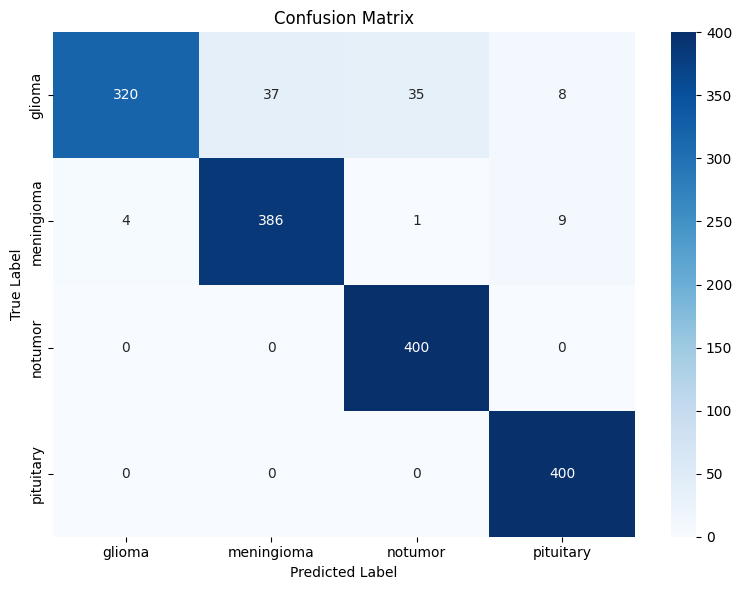

In [ ]:
model.load_state_dict(
torch.load(
    'best_model_SEW18_brain_tumor.pth',
    weights_only=True,
    map_location=device
)
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True
)

model.eval()
criterion = nn.CrossEntropyLoss()

correct, total = 0, 0
total_loss = 0

all_preds = []
all_labels = []

print("\nRunning evaluation...")
with torch.no_grad():
    pbar = tqdm(testloader)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        preds = outputs.argmax(1)

        total_loss += loss.item()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        functional.reset_net(model)

        pbar.set_postfix(acc=correct / total)

acc = correct / total
avg_loss = total_loss / len(testloader)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print("\n===== RESULTS =====")
print(f"Accuracy       : {acc:.4f}")
print(f"Loss           : {avg_loss:.4f}")
print(f"F1 (macro)     : {f1_macro:.4f}")
print(f"F1 (weighted)  : {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=testset.classes))
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=testset.classes,
    yticklabels=testset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()